# ESG & Financial Performance Analysis

This notebook replicates the analysis from the Streamlit dashboard in a static, reproducible format. It explores the relationship between ESG scores and financial metrics using the Kaggle dataset.

**Problem**: Does a company's ESG score correlate with profit margin, revenue, and market cap?

**Target audience**: Investors and sustainability analysts.

**Workflow**:
1. Load and inspect data
2. Clean and create ESG categories
3. Generate six visualizations
4. Summarize key findings and limitations

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Inspect Data

In [2]:
df = pd.read_csv('esg_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (11000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [3]:
df.isnull().sum()

CompanyID               0
CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
dtype: int64

In [4]:
numeric_cols = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
                'ProfitMargin', 'Revenue', 'MarketCap', 'GrowthRate']
df[numeric_cols].describe()

,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,ProfitMargin,Revenue,MarketCap,GrowthRate
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000
mean,54.615273,56.416991,55.660582,51.767655,10.900455,4670.850591,13380.622236,4.830370
std,15.893937,26.767233,23.356152,25.323370,8.758711,9969.954369,39922.870373,9.424787
min,6.300000,0.000000,0.000000,0.000000,-20.000000,35.900000,1.800000,-36.000000
25%,44.100000,34.700000,37.600000,30.775000,5.300000,938.775000,1098.525000,-1.325000
50%,54.600000,55.600000,55.150000,52.100000,10.500000,1902.300000,3096.450000,4.900000
75%,65.600000,79.000000,73.800000,73.000000,16.300000,4342.625000,9995.500000,11.000000
max,98.800000,100.000000,100.000000,100.000000,50.000000,180810.400000,865271.700000,38.000000


## 3. Data Cleaning & Preprocessing

In [5]:
df_clean = df.dropna(subset=['ESG_Overall', 'ProfitMargin', 'Revenue', 'MarketCap'])
print(f'Rows after dropping missing: {len(df_clean)}')

df_clean['ESG_Category'] = pd.qcut(df_clean['ESG_Overall'], q=3, labels=['Low', 'Medium', 'High'])
df_clean['ESG_Category'].value_counts()

Rows after dropping missing: 11000


ESG_Category
Medium    3677
Low       3668
High      3655
Name: count, dtype: int64

## 4. Visualizations

### 4.1 ESG Overall Score vs Profit Margin (with Trend Line)

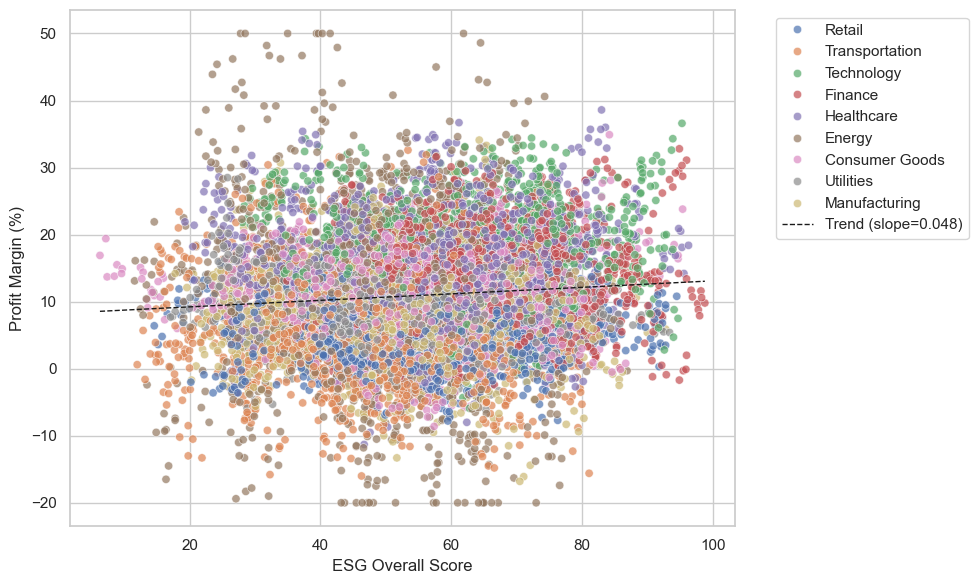

In [6]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_clean, x='ESG_Overall', y='ProfitMargin', hue='Industry', alpha=0.7, ax=ax)

z = np.polyfit(df_clean['ESG_Overall'], df_clean['ProfitMargin'], 1)
p = np.poly1d(z)
x_trend = np.sort(df_clean['ESG_Overall'])
ax.plot(x_trend, p(x_trend), 'k--', linewidth=1, label=f'Trend (slope={z[0]:.3f})')

ax.set_xlabel('ESG Overall Score')
ax.set_ylabel('Profit Margin (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.2 Average Profit Margin by ESG Category (with Error Bars)

C:\Users\fxl66\AppData\Local\Temp\ipykernel_18048\538476667.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_profit, x='ESG_Category', y='mean', palette='viridis', ax=ax)


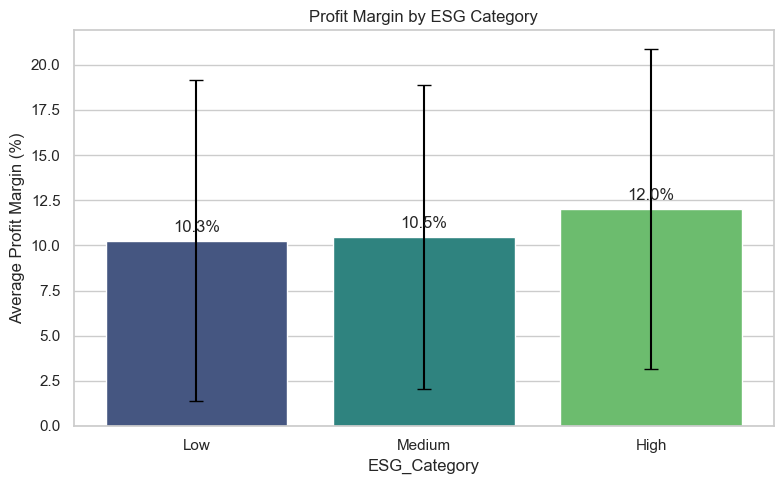

In [7]:
avg_profit = df_clean.groupby('ESG_Category')['ProfitMargin'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=avg_profit, x='ESG_Category', y='mean', palette='viridis', ax=ax)
ax.errorbar(x=range(len(avg_profit)), y=avg_profit['mean'], yerr=avg_profit['std'],
            fmt='none', c='black', capsize=5)
for i, row in avg_profit.iterrows():
    ax.text(i, row['mean'] + 0.5, f"{row['mean']:.1f}%", ha='center')
ax.set_ylabel('Average Profit Margin (%)')
ax.set_title('Profit Margin by ESG Category')
plt.tight_layout()
plt.show()

### 4.3 Profit Margin Trend Over Time by ESG Category

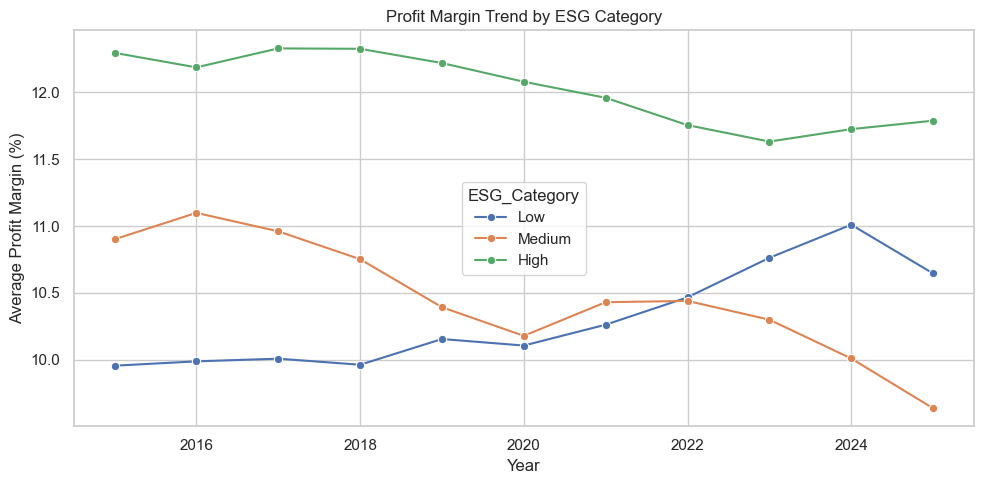

In [8]:
trend_data = df_clean.groupby(['Year', 'ESG_Category'])['ProfitMargin'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=trend_data, x='Year', y='ProfitMargin', hue='ESG_Category', marker='o', ax=ax)
ax.set_ylabel('Average Profit Margin (%)')
ax.set_title('Profit Margin Trend by ESG Category')
plt.tight_layout()
plt.show()

### 4.4 ESG Overall Score Trend by Industry

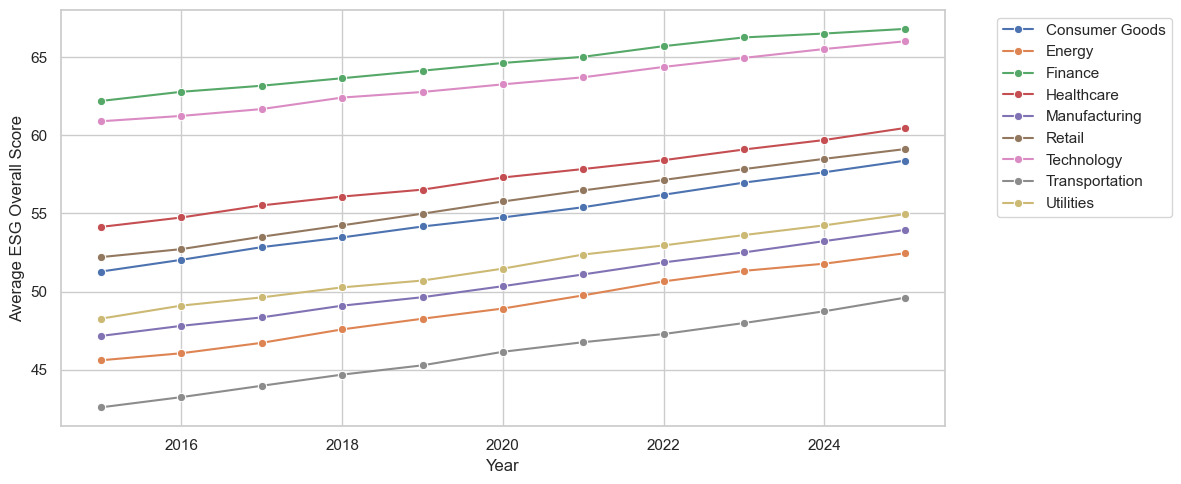

In [9]:
trend_esg = df_clean.groupby(['Year', 'Industry'])['ESG_Overall'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(data=trend_esg, x='Year', y='ESG_Overall', hue='Industry', marker='o', ax=ax)
ax.set_ylabel('Average ESG Overall Score')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.5 Correlation Matrix

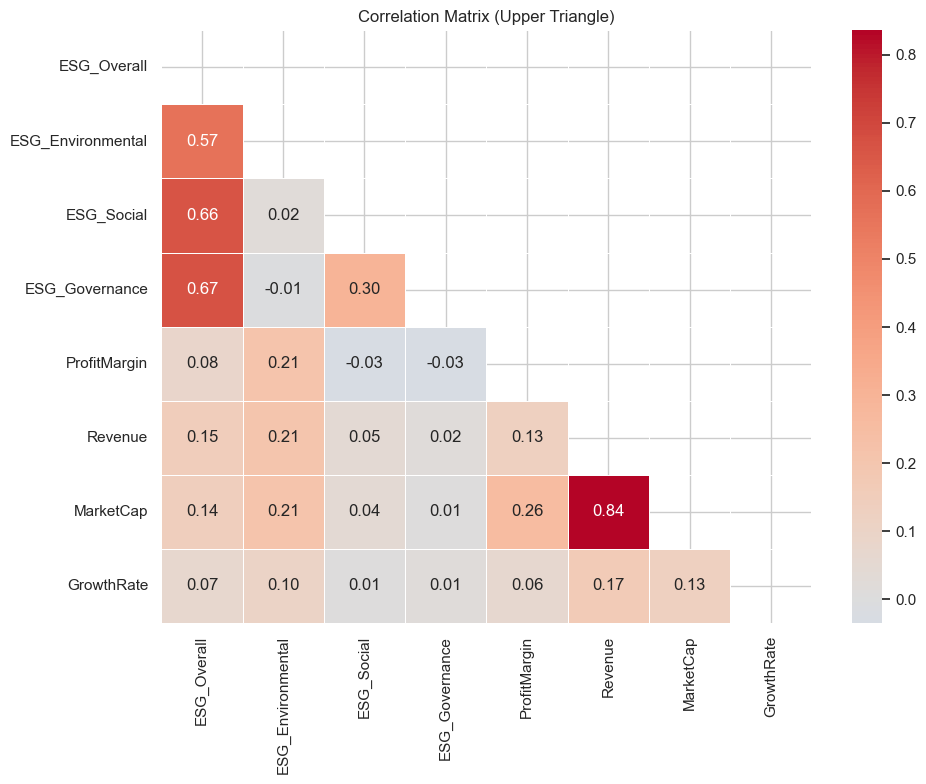

In [10]:
corr_cols = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
             'ProfitMargin', 'Revenue', 'MarketCap', 'GrowthRate']
corr_data = df_clean[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Upper Triangle)')
plt.tight_layout()
plt.show()

### 4.6 Industry Bubble Chart (Size = Market Cap)

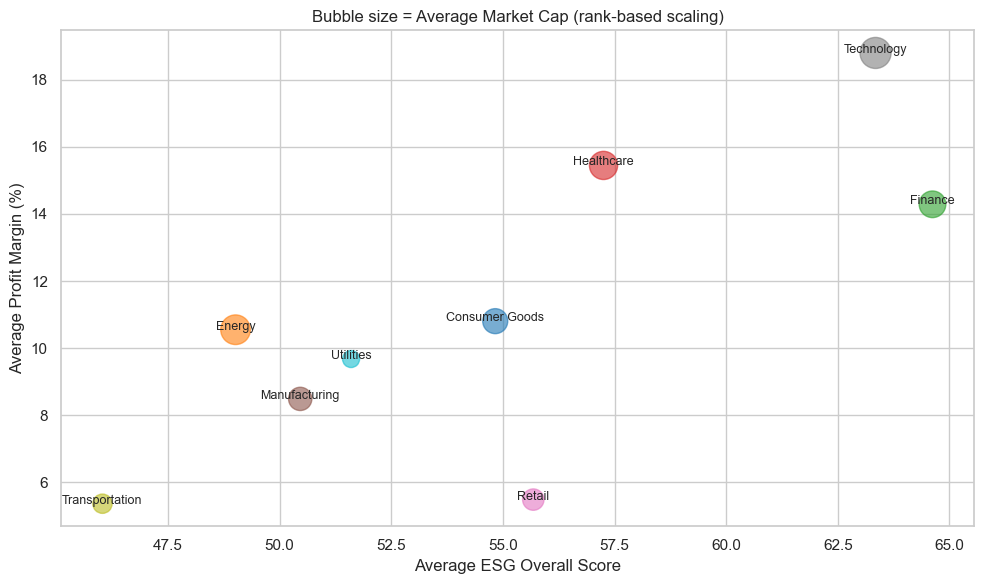

In [11]:
industry_agg = df_clean.groupby('Industry').agg({
    'ESG_Overall': 'mean',
    'ProfitMargin': 'mean',
    'MarketCap': 'mean'
}).reset_index()
industry_agg.dropna(inplace=True)

industry_agg['Rank'] = industry_agg['MarketCap'].rank(method='dense')
min_rank = industry_agg['Rank'].min()
max_rank = industry_agg['Rank'].max()
sizes = 150 + (industry_agg['Rank'] - min_rank) / (max_rank - min_rank) * (500 - 150)

fig, ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(
    industry_agg['ESG_Overall'], industry_agg['ProfitMargin'],
    s=sizes, alpha=0.6, c=range(len(industry_agg)), cmap='tab10'
)
for i, row in industry_agg.iterrows():
    ax.annotate(row['Industry'], (row['ESG_Overall'], row['ProfitMargin']), fontsize=9, ha='center')
ax.set_xlabel('Average ESG Overall Score')
ax.set_ylabel('Average Profit Margin (%)')
ax.set_title('Bubble size = Average Market Cap (rank-based scaling)')
plt.tight_layout()
plt.show()

### 4.7 Revenue vs Market Cap (Log-Log Scale)

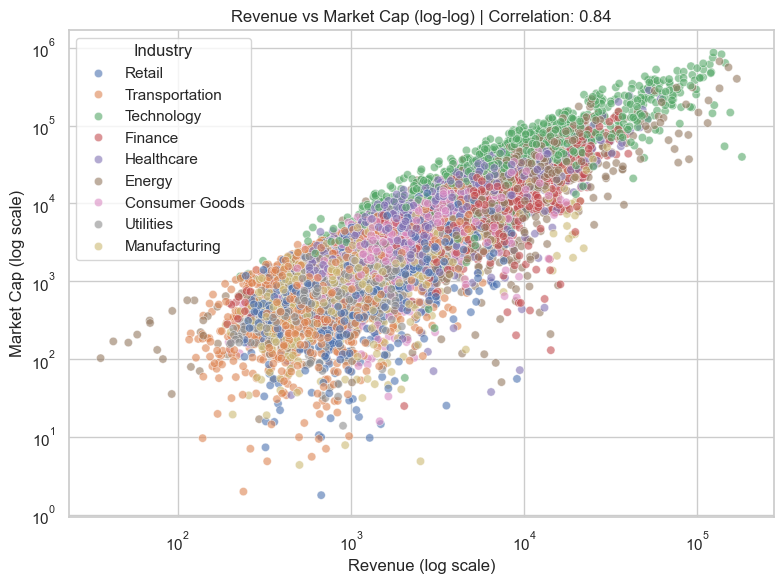

In [12]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_clean, x='Revenue', y='MarketCap', hue='Industry', alpha=0.6, ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Revenue (log scale)')
ax.set_ylabel('Market Cap (log scale)')
corr_val = df_clean[['Revenue', 'MarketCap']].corr().iloc[0,1]
ax.set_title(f'Revenue vs Market Cap (log-log) | Correlation: {corr_val:.2f}')
plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [13]:
df_clean[numeric_cols].describe()

,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,ProfitMargin,Revenue,MarketCap,GrowthRate
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000
mean,54.615273,56.416991,55.660582,51.767655,10.900455,4670.850591,13380.622236,4.830370
std,15.893937,26.767233,23.356152,25.323370,8.758711,9969.954369,39922.870373,9.424787
min,6.300000,0.000000,0.000000,0.000000,-20.000000,35.900000,1.800000,-36.000000
25%,44.100000,34.700000,37.600000,30.775000,5.300000,938.775000,1098.525000,-1.325000
50%,54.600000,55.600000,55.150000,52.100000,10.500000,1902.300000,3096.450000,4.900000
75%,65.600000,79.000000,73.800000,73.000000,16.300000,4342.625000,9995.500000,11.000000
max,98.800000,100.000000,100.000000,100.000000,50.000000,180810.400000,865271.700000,38.000000


## 6. Key Findings & Conclusions

1. **ESG vs Profit Margin** – Very weak positive correlation (slope ≈ 0.09).
2. **ESG Category Comparison** – Small differences; error bars overlap.
3. **Time Trends** – Profit margins stable; ESG scores slowly rising.
4. **Correlation Matrix** – ESG_Overall vs ProfitMargin = 0.088; Revenue vs MarketCap = 0.84.
5. **Industry Bubble Chart** – Large market cap industries (Tech, Finance) have high ESG scores but not necessarily high margins.
6. **Log-log Relationship** – Revenue and market cap strongly correlated.

**Implication**: ESG alone is not a reliable predictor of short-term profitability. Use as a non-financial risk indicator, combined with traditional analysis.

**Limitations**: Cross-sectional data, missing control variables, single ESG provider.

**Data source**: Kaggle – Synthetic ESG & Financial Performance Dataset (accessed April 2026).